In [4]:
df_links = pd.read_csv("Url swisse - Sheet1.csv")

all_urls = [
    str(url).strip()
    for url in df_links.iloc[:, 0]
    if str(url).startswith("http")
]

In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

results = []

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-AU,en;q=0.9"
}

batch_size = 20  # 每次跑20个

for i in range(0, len(all_urls), batch_size):
    batch = all_urls[i:i+batch_size]

    print(f"🚀 Processing batch {i} to {i+batch_size}")

    for url in batch:
        try:
            res = requests.get(url, headers=headers)
            soup = BeautifulSoup(res.text, "html.parser")

            title = soup.find("h1")
            title = title.text.strip() if title else "N/A"

            text = soup.get_text()

            ingredients_section = ""
            for keyword in ["Ingredients", "Active Ingredients", "Contains"]:
                if keyword in text:
                    ingredients_section = text.split(keyword)[1][:800]
                    break

            results.append({
                "Product": title,
                "URL": url,
                "Ingredients": ingredients_section
            })

            print(f"✔ {title}")
            time.sleep(random.uniform(1.5, 3))

        except:
            print(f"❌ Error: {url}")

    # ⭐ 每一批保存一次（防止崩掉）
    pd.DataFrame(results).to_csv("swisse_ingredients_progress.csv", index=False)

print("✅ 全部抓取完成")

🚀 Processing batch 0 to 20
✔ Swisse Mens Multivitamin 120 Tablets
✔ Swisse Calcium + Vitamin D 300 Mini Tablets
✔ Swisse Ultiboost Liver Detox 200 Tablets
✔ Swisse Ultiboost Co Enzyme Q10 150mg 180 Capsules
✔ Swisse Beauty Bright Skin 120 Capsules
✔ Swisse Ultiboost Magnesium Glycinate 120 Tablets
✔ Swisse Ultiboost Grape Seed 14250mg 300 Tablets
✔ Swisse Ultiboost Odourless High Strength Wild Fish Oil 1500mg 200 Capsules
✔ Swisse Beauty Hair Skin Nails+ 100 Tablets
✔ Swisse Magnesium Calcium + Vitamin D 200 Tablets
✔ Swisse Ultiboost Sleep 100 Tablets
✔ Swisse Milk Thistle 35000mg 60 Tablets
✔ Swisse Ultiboost Iron 30 Tablets
✔ Swisse Vitamin D 500 Capsules Exclusive Size
✔ Swisse Ultiboost Calcium + Vitamin D 150 Tablets
✔ Swisse Ultiboost Magnesium + Sleep 60 Tablets
✔ Swisse Beauty Collagen Glow With Collagen Peptides 120 Tablets
✔ Swisse Ultiboost Odourless Super Strength Wild Fish Oil 2000mg 200 Capsules
✔ Swisse Glucosamine Sulfate 1500mg 180 Tablets
✔ Swisse Womens Multivitamin

In [6]:
import pandas as pd
import re

# 读取你刚生成的文件
df = pd.read_csv("swisse_ingredients_progress.csv")

structured_data = []

for _, row in df.iterrows():
    product = row["Product"]
    ingredients_text = str(row["Ingredients"])

    # 拆分（更强版本）
    parts = re.split(r";|\n|:", ingredients_text)

    for part in parts:
        part = part.strip()

        # 提取 成分 + 数值
        match = re.search(r"([A-Za-z\s\(\)\-]+)\s(\d+\.?\d*\s?(mg|µg|g|IU))", part)

        if match:
            ingredient = match.group(1).strip()
            dosage = match.group(2).strip()

            structured_data.append({
                "Product": product,
                "Ingredient": ingredient,
                "Dosage": dosage
            })

structured_df = pd.DataFrame(structured_data)

# 保存
structured_df.to_csv("structured_ingredients.csv", index=False)

print("✅ 成分拆解完成")

✅ 成分拆解完成


In [7]:
# 去掉明显不是成分的行
clean_df = structured_df[
    ~structured_df["Ingredient"].str.contains(
        "dose|daily|maximum|serving|recommended",
        case=False,
        na=False
    )
]

# 去掉太短/无意义的词
clean_df = clean_df[
    clean_df["Ingredient"].str.len() > 3
]

# 保存干净版本
clean_df.to_csv("clean_ingredients.csv", index=False)

print("✅ 清洗完成")

✅ 清洗完成


In [8]:
clean_df = structured_df[
    ~structured_df["Ingredient"].str.contains(
        "dose|daily|maximum|serving|recommended|leaf",
        case=False,
        na=False
    )
]

# 去掉太短的
clean_df = clean_df[
    clean_df["Ingredient"].str.len() > 4
]

clean_df.to_csv("clean_ingredients_final.csv", index=False)

print("✅ 最终清洗完成")

✅ 最终清洗完成


In [9]:
import pandas as pd
import re

df = pd.read_csv("clean_ingredients_final.csv")

def clean_ingredient(name):
    name = str(name)

    # 去括号
    name = re.sub(r"\(.*?\)", "", name)

    # 去 from xxx
    name = re.sub(r"from .*", "", name, flags=re.IGNORECASE)

    # 去多余空格
    name = name.strip()

    # 首字母大写
    name = name.title()

    return name

df["Ingredient_clean"] = df["Ingredient"].apply(clean_ingredient)

# 去掉空的
df = df[df["Ingredient_clean"].str.len() > 2]

df.to_csv("final_ingredients.csv", index=False)

print("✅ 成分标准化完成")

✅ 成分标准化完成


clean data is done here

Here we will see ingrident frequency

In [10]:
df["Ingredient_clean"].value_counts().head(30)

Ingredient_clean
Vitamin C                                      66
Magnesium                                      54
Calcium                                        35
Nicotinamide                                   33
Vitamin E                                      33
Zinc                                           29
Biotin                                         24
Iron                                           22
Copper                                         18
Folic Acid                                     13
Iodine                                         13
Chromium                                       13
Manganese                                      12
Milk Thistle (Silybum Marianum Extract          9
Eicosapentaenoic Acid                           8
Vitamin A                                       7
Hydrolysed Collagen                             7
Passionflower (Passiflora Incarnata Extract     7
Hops (Humulus Lupulus Extract                   7
Inositol                         

In [11]:
from itertools import combinations
from collections import Counter
import pandas as pd

combo_counter = Counter()

for product, group in df.groupby("Product"):
    ingredients = group["Ingredient_clean"].dropna().unique()
    for combo in combinations(sorted(ingredients), 2):
        combo_counter[combo] += 1

combo_df = pd.DataFrame(
    [(a, b, count) for (a, b), count in combo_counter.items()],
    columns=["Ingredient_1", "Ingredient_2", "Co_occurrence_Count"]
)

combo_df = combo_df.sort_values(by="Co_occurrence_Count", ascending=False)
combo_df.head(20)

,Ingredient_1,Ingredient_2,Co_occurrence_Count
16,Vitamin C,Vitamin E,32
3,Nicotinamide,Vitamin C,26
5,Vitamin C,Zinc,25
77,Calcium,Vitamin C,24
88,Magnesium,Vitamin C,24
15,Nicotinamide,Vitamin E,23
75,Calcium,Magnesium,23
54,Iron,Vitamin C,21
76,Calcium,Nicotinamide,21
78,Calcium,Vitamin E,20


## Visualisation of Top Ingredients

This chart visualises the most frequently occurring ingredients in the dataset.  
It provides an intuitive overview of which ingredients dominate the supplement market and helps identify major formulation trends.

In [12]:
ingredient_count = df.groupby("Product")["Ingredient_clean"].nunique()

ingredient_count.describe()

count    151.000000
mean       4.105960
std        3.843874
min        1.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       20.000000
Name: Ingredient_clean, dtype: float64

In [13]:
single = ingredient_count[ingredient_count == 1]
multi = ingredient_count[ingredient_count > 1]
print("Number of single-ingredient products:", len(single))
print("Number of multi-ingredient products:", len(multi))

Number of single-ingredient products: 57
Number of multi-ingredient products: 94


## Single-ingredient vs Multi-ingredient Products

This section classifies products into single-ingredient and multi-ingredient categories based on the number of unique ingredients in each product.  
This provides a clearer understanding of how the market is divided between simple nutritional supplements and more complex blended formulations.

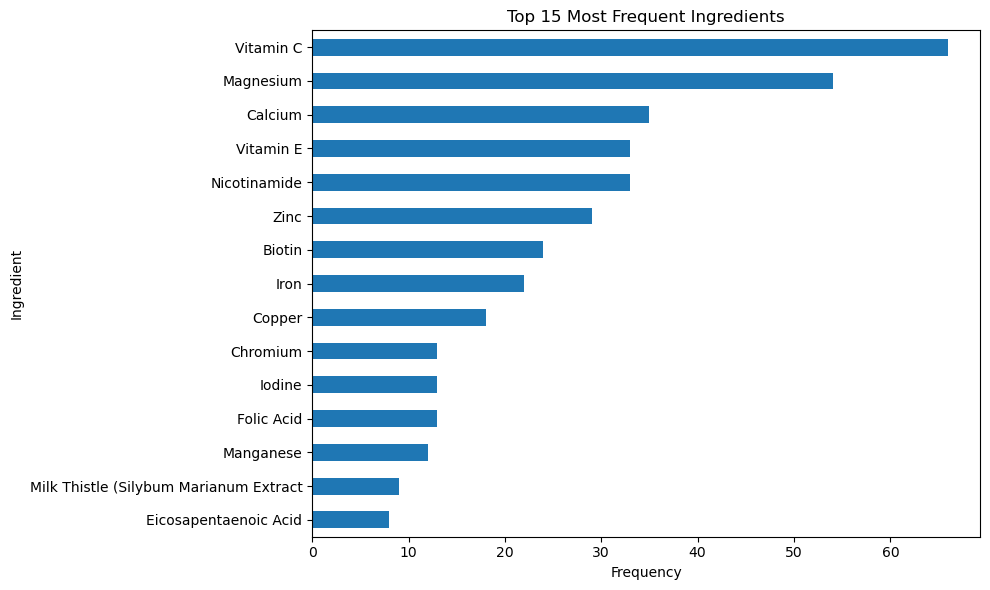

In [14]:
import matplotlib.pyplot as plt

top = df["Ingredient_clean"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top.sort_values().plot(kind="barh")
plt.title("Top 15 Most Frequent Ingredients")
plt.xlabel("Frequency")
plt.ylabel("Ingredient")
plt.tight_layout()
plt.show()

## Ingredient Frequency Analysis

This section examines how often each cleaned ingredient appears across all products.  
A higher frequency indicates that the ingredient is commonly used in the supplement product range.  
This helps identify the most prevalent nutrients and active compounds in the dataset.

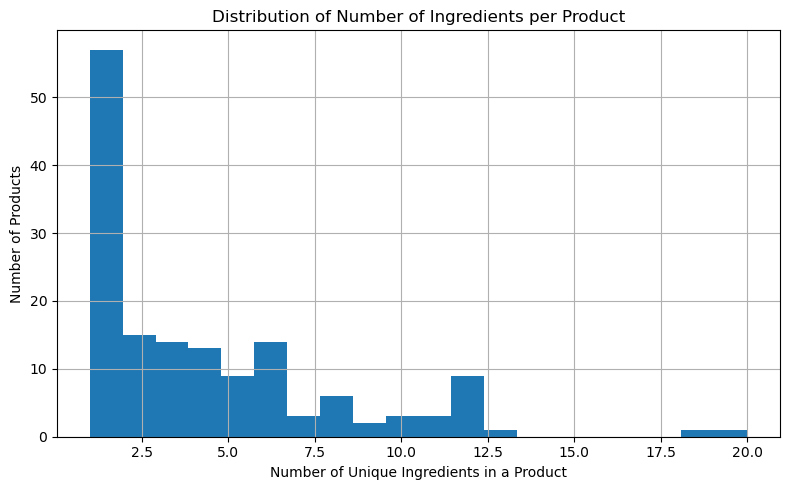

In [15]:
plt.figure(figsize=(8, 5))
ingredient_count.hist(bins=20)
plt.title("Distribution of Number of Ingredients per Product")
plt.xlabel("Number of Unique Ingredients in a Product")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

## Product Complexity Summary

This section measures the number of unique ingredients contained in each product.  
Descriptive statistics are used to summarise the overall distribution of product complexity, including the average, median, minimum, and maximum number of ingredients.  
This helps distinguish simple single-ingredient supplements from more complex multi-ingredient formulations.

In [18]:
df.columns

Index(['Product', 'Ingredient', 'Dosage', 'Ingredient_clean'], dtype='object')

In [19]:
df_valid = df.dropna(subset=["Dosage"])

In [20]:
grouped = df.groupby("Ingredient_clean")

In [37]:
def convert_to_mg(dosage):
    try:
        dosage = str(dosage).strip()
        if "µg" in dosage:
            return float(dosage.replace("µg", "").strip()) / 1000
        elif "mg" in dosage:
            return float(dosage.replace("mg", "").strip())
        elif "g" in dosage:
            return float(dosage.replace("g", "").strip()) * 1000
        else:
            return None
    except:
        return None


# 2️⃣ 创建 Dosage_mg 列
df_clean["Dosage_mg"] = df_clean["Dosage"].apply(convert_to_mg)

# 3️⃣ 检查是否成功
print(df_clean[["Dosage", "Dosage_mg"]].head(10))
print(df_clean["Dosage_mg"].dtype)

      Dosage  Dosage_mg
0      50 µg     0.0500
1     500 µg     0.5000
2      25 mg    25.0000
8     165 mg   165.0000
10  24.79 mg    24.7900
11     21 mg    21.0000
12    6.2 µg     0.0062
13     58 µg     0.0580
14     50 µg     0.0500
15      3 mg     3.0000
float64


In [38]:
invalid_keywords = [
    "fresh", "dry", "chew", "to", "fruit", "root",
    "serving", "dose", "daily", "recommended"
]

df_clean = df_valid[
    ~df_valid["Ingredient_clean"].str.lower().str.contains("|".join(invalid_keywords))
].copy()

In [39]:
def normalize_ingredient(name):
    name = str(name).lower()

    if "collagen" in name:
        return "Collagen"
    if "vitamin c" in name or "ascorbic" in name:
        return "Vitamin C"
    if "epa" in name or "eicosapentaenoic" in name:
        return "EPA"
    if "dha" in name or "docosahexaenoic" in name:
        return "DHA"
    if "fish oil" in name or "triglyceride" in name:
        return None
    if "glucosamine" in name:
        return "Glucosamine"
    if "withania" in name or "ashwagandha" in name:
        return "Ashwagandha"
    if "magnesium" in name:
        return "Magnesium"
    if "zinc" in name:
        return "Zinc"
    if "calcium" in name:
        return "Calcium"

    return name.strip().title()

df_clean["Ingredient_final"] = df_clean["Ingredient_clean"].apply(normalize_ingredient)
df_clean = df_clean.dropna(subset=["Ingredient_final"]).copy()

## Recreate Dosage_mg Column

In [41]:
def convert_to_mg(dosage):
    try:
        dosage = str(dosage).strip()
        if "µg" in dosage:
            return float(dosage.replace("µg", "").strip()) / 1000
        elif "mg" in dosage:
            return float(dosage.replace("mg", "").strip())
        elif "g" in dosage:
            return float(dosage.replace("g", "").strip()) * 1000
        else:
            return None
    except:
        return None

df_clean["Dosage_mg"] = df_clean["Dosage"].apply(convert_to_mg)

In [42]:
df_clean[["Dosage", "Dosage_mg"]].head(10)

,Dosage,Dosage_mg
0,50 µg,0.0500
1,500 µg,0.5000
2,25 mg,25.0000
8,165 mg,165.0000
10,24.79 mg,24.7900
11,21 mg,21.0000
12,6.2 µg,0.0062
13,58 µg,0.0580
14,50 µg,0.0500
15,3 mg,3.0000


In [43]:
df_clean["Dosage_mg"] = df_clean["Dosage"].apply(convert_to_mg)

In [44]:
import pandas as pd

df_clean["Dosage_mg"] = pd.to_numeric(df_clean["Dosage_mg"], errors="coerce")
df_clean = df_clean.dropna(subset=["Dosage_mg"]).copy()

idx = df_clean.groupby("Ingredient_final")["Dosage_mg"].idxmax()

top_by_ingredient = df_clean.loc[idx].copy()
top_by_ingredient = top_by_ingredient.sort_values("Dosage_mg", ascending=False)

top_by_ingredient.head(20)

,Product,Ingredient,Dosage,Ingredient_clean,Ingredient_final,Dosage_mg
599,Swisse Beauty High Strength Marine Collagen+ U...,Hydrolysed Collagen,10 g,Hydrolysed Collagen,Collagen,10000.00
366,Swisse Collagen Joint + Muscle Health Powder 162g,Glucosamine Sulfate (from glucosamine sulfate ...,1.89 g,Glucosamine Sulfate (,Glucosamine,1890.00
160,Swisse High Strength Curcumin 30 Tablets,Turmeric (Curcuma longa extract,1.263 g,Turmeric (Curcuma Longa Extract,Turmeric (Curcuma Longa Extract,1263.00
663,Swisse Ultiboost Lecithin 1200mg 150 Caps,Lecithin,1.2 g,Lecithin,Lecithin,1200.00
176,Swisse Vitamin C 60 Effervescent Tablets,Vitamin C (ascorbic acid),1 g,Vitamin C,Vitamin C,1000.00
222,Swisse Ultiboost 4 x Strength Wild Fish Oil Co...,Eicosapentaenoic acid (EPA),720 mg,Eicosapentaenoic Acid,EPA,720.00
429,Swisse Ultiboost High Strength Ashwagandha 60 ...,(Withania somnifera Extract,600 mg,(Withania Somnifera Extract,Ashwagandha,600.00
375,Swisse Beauty Acne Support 60 Tablets,Milk Thistle (Silybum marianum extract,518.50 mg,Milk Thistle (Silybum Marianum Extract,Milk Thistle (Silybum Marianum Extract,518.50
556,Swisse Ultiboost Joint Pain Relief 90 Tablets,MSM (as dimethyl sulfone),500 mg,Msm,Msm,500.00
424,Swisse Ultiboost Vitamin B3 120 Tablets,Nicotinamide,500mg,Nicotinamide,Nicotinamide,500.00


In [47]:
def ingredient_type(name):
    if name in ["Vitamin C", "Vitamin E", "Vitamin A"]:
        return "Vitamin"
    
    if name in ["Magnesium", "Calcium", "Zinc", "Iron"]:
        return "Mineral"
    
    if name in ["Collagen", "Glucosamine", "Chondroitin", "MSM"]:
        return "Structural"
    
    if name in ["EPA", "DHA", "Lecithin"]:
        return "Fatty Acid"
    
    return "Herbal"

<Axes: xlabel='Category'>

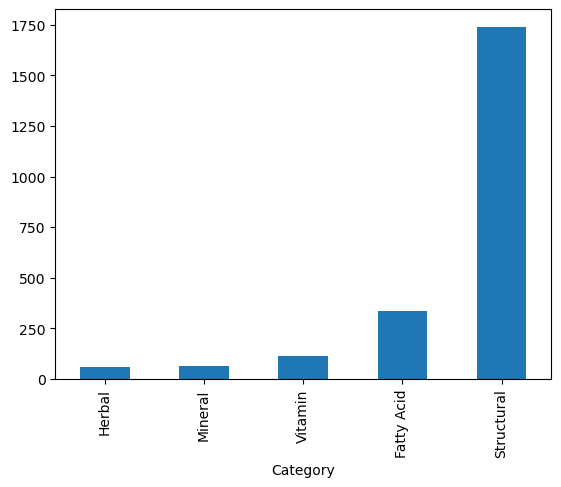

In [49]:
df_clean["Category"] = df_clean["Ingredient_final"].apply(ingredient_type)

df_clean.groupby("Category")["Dosage_mg"].mean().sort_values().plot(kind="bar")

<Axes: xlabel='Category'>

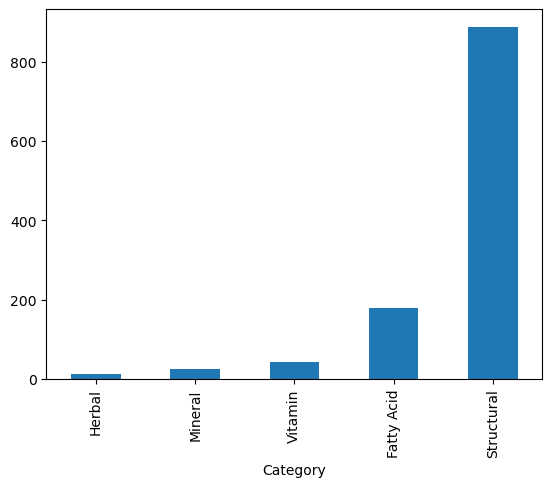

In [50]:
df_clean.groupby("Category")["Dosage_mg"].median().sort_values().plot(kind="bar")

most value to buy

In [51]:
# 1️⃣ 确保 Dosage_mg 是数值
df_clean["Dosage_mg"] = pd.to_numeric(df_clean["Dosage_mg"], errors="coerce")

# 2️⃣ 删除无效数据
df_valid = df_clean.dropna(subset=["Dosage_mg"])

# 3️⃣ 找每个产品最高剂量的成分
idx = df_valid.groupby("Product")["Dosage_mg"].idxmax()

top_product_strength = df_valid.loc[idx].copy()

# 4️⃣ 排序（最强产品在前）
top_product_strength = top_product_strength.sort_values("Dosage_mg", ascending=False)

# 5️⃣ 查看前20
top_product_strength[["Product", "Ingredient_final", "Dosage_mg"]].head(20)

,Product,Ingredient_final,Dosage_mg
599,Swisse Beauty High Strength Marine Collagen+ U...,Collagen,10000.00
592,Swisse Beauty Marine Collagen Skin Hydration 1...,Collagen,3000.00
259,Swisse Beauty Collagen Glow Powder 240g,Collagen,2500.00
695,Swisse Beauty Collagen Glow Powder 120g,Collagen,2500.00
366,Swisse Collagen Joint + Muscle Health Powder 162g,Glucosamine,1890.00
63,Swisse Glucosamine Sulfate 1500mg 180 Tablets,Glucosamine,1500.00
160,Swisse High Strength Curcumin 30 Tablets,Turmeric (Curcuma Longa Extract,1263.00
245,Swisse Beauty High Strength Collagen 60 Tablets,Collagen,1250.00
664,Swisse Ultiboost Lecithin 1200mg 300 Capsules,Lecithin,1200.00
663,Swisse Ultiboost Lecithin 1200mg 150 Caps,Lecithin,1200.00


<Axes: xlabel='Product'>

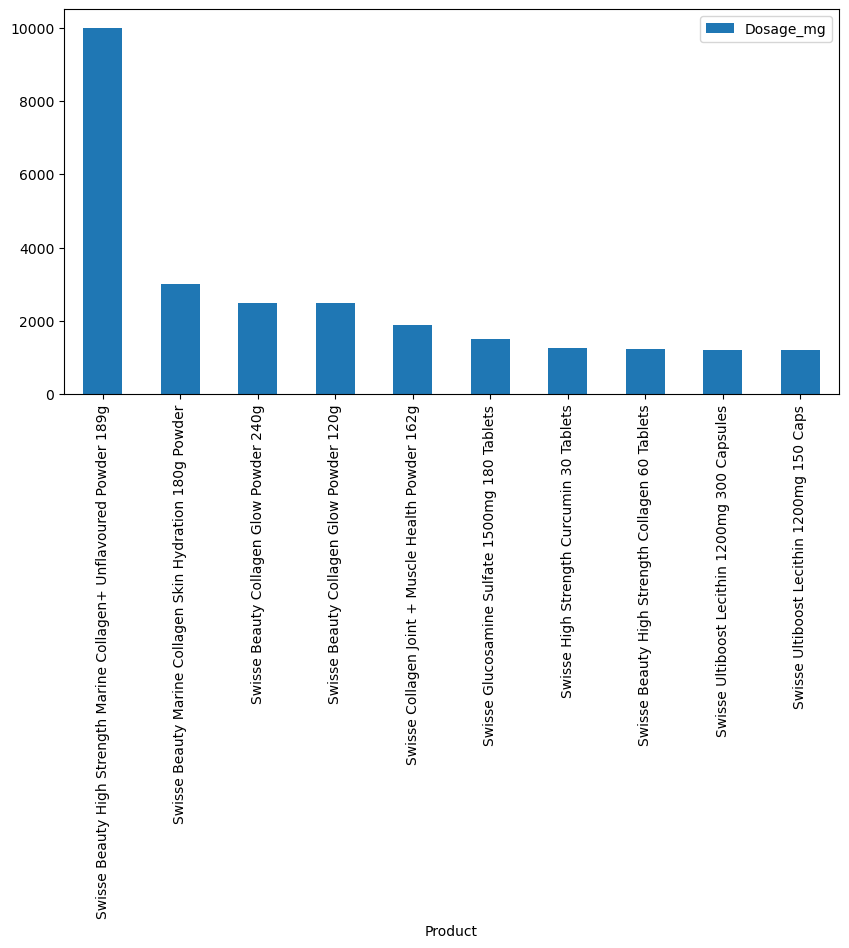

In [52]:
top_product_strength.head(10).plot(
    x="Product",
    y="Dosage_mg",
    kind="bar",
    figsize=(10,5)
)

now i feel like not evey element need to be highest cuz some of them we don't need that mucn. So now i use two different ways to define what is the good products.

In [70]:
df_clean

,Product,Ingredient,Dosage,Ingredient_clean,Ingredient_final,Dosage_mg,Category,RDI_score,RDI_score_capped,Market_score
0,Swisse Mens Multivitamin 120 Tablets,Biotin,50 µg,Biotin,Biotin,0.05,Herbal,NaN,NaN,0.003871
1,Swisse Mens Multivitamin 120 Tablets,Folic acid,500 µg,Folic Acid,Folic Acid,0.50,Herbal,NaN,NaN,0.038715
2,Swisse Mens Multivitamin 120 Tablets,Nicotinamide,25 mg,Nicotinamide,Nicotinamide,25.00,Herbal,NaN,NaN,1.935734
8,Swisse Mens Multivitamin 120 Tablets,Vitamin C (ascorbic acid),165 mg,Vitamin C,Vitamin C,165.00,Vitamin,1.833333,1.833333,3.992257
10,Swisse Mens Multivitamin 120 Tablets,Vitamin E (d-alpha-tocopheryl acid succinate),24.79 mg,Vitamin E,Vitamin E,24.79,Vitamin,NaN,NaN,0.599806
...,...,...,...,...,...,...,...,...,...,...
756,Swisse Nutra Cellular Energy 60 Tablets,Quercetin dihydrate,85 mg,Quercetin Dihydrate,Quercetin Dihydrate,85.00,Herbal,NaN,NaN,6.581494
757,Swisse Nutra Cellular Energy 60 Tablets,Nicotinamide,250mg,Nicotinamide,Nicotinamide,250.00,Herbal,NaN,NaN,19.357336
758,Swisse Nutra Cellular Energy 60 Tablets,R-alpha lipoic acid,150 mg,R-Alpha Lipoic Acid,R-Alpha Lipoic Acid,150.00,Herbal,NaN,NaN,11.614402
759,Swisse Nutra Cellular Joint Mobility 30 Tablets,Chicken sternum cartilage powder,40 mg,Chicken Sternum Cartilage Powder,Chicken Sternum Cartilage Powder,40.00,Herbal,NaN,NaN,3.097174


## Dual Scoring System for Product Evaluation

This section evaluates products using a dual scoring framework.

For vitamins and minerals, dosage is compared against recommended daily intake (RDI) values.  
For other supplement categories, dosage is compared against the market median within each category.

This approach avoids applying one single standard to all supplement types and provides a more balanced product evaluation framework.

In [71]:
# Check required columns
print(df_clean.columns)

required_cols = ["Product", "Ingredient_final", "Dosage_mg", "Category"]
missing_cols = [col for col in required_cols if col not in df_clean.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are present.")

Index(['Product', 'Ingredient', 'Dosage', 'Ingredient_clean',
       'Ingredient_final', 'Dosage_mg', 'Category', 'RDI_score',
       'RDI_score_capped', 'Market_score'],
      dtype='object')
All required columns are present.


In [72]:
import pandas as pd
import numpy as np

# Make sure Dosage_mg is numeric
df_clean["Dosage_mg"] = pd.to_numeric(df_clean["Dosage_mg"], errors="coerce")

# Remove rows without valid dosage
df_clean = df_clean.dropna(subset=["Dosage_mg"]).copy()

print(df_clean[["Product", "Ingredient_final", "Dosage_mg", "Category"]].head())

                                 Product Ingredient_final  Dosage_mg Category
0   Swisse Mens Multivitamin 120 Tablets           Biotin       0.05   Herbal
1   Swisse Mens Multivitamin 120 Tablets       Folic Acid       0.50   Herbal
2   Swisse Mens Multivitamin 120 Tablets     Nicotinamide      25.00   Herbal
8   Swisse Mens Multivitamin 120 Tablets        Vitamin C     165.00  Vitamin
10  Swisse Mens Multivitamin 120 Tablets        Vitamin E      24.79  Vitamin


In [73]:
# Recommended Daily Intake (all converted to mg)
rdi = {
    "Vitamin C": 90,       # mg
    "Vitamin D": 0.015,    # 15 µg = 0.015 mg
    "Vitamin E": 15,       # mg
    "Vitamin A": 0.9,      # 900 µg = 0.9 mg
    "Calcium": 1000,       # mg
    "Magnesium": 400,      # mg
    "Zinc": 11,            # mg
    "Iron": 18             # mg
}

print(rdi)

{'Vitamin C': 90, 'Vitamin D': 0.015, 'Vitamin E': 15, 'Vitamin A': 0.9, 'Calcium': 1000, 'Magnesium': 400, 'Zinc': 11, 'Iron': 18}


In [74]:
def rdi_score(row):
    ingredient = row["Ingredient_final"]
    dosage = row["Dosage_mg"]
    
    if ingredient in rdi:
        return dosage / rdi[ingredient]
    else:
        return np.nan

df_clean["RDI_score_raw"] = df_clean.apply(rdi_score, axis=1)

df_clean[["Ingredient_final", "Dosage_mg", "RDI_score_raw"]].head(10)

,Ingredient_final,Dosage_mg,RDI_score_raw
0,Biotin,0.0500,NaN
1,Folic Acid,0.5000,NaN
2,Nicotinamide,25.0000,NaN
8,Vitamin C,165.0000,1.833333
10,Vitamin E,24.7900,1.652667
11,Calcium,21.0000,0.021000
12,Chromium,0.0062,NaN
13,Copper,0.0580,NaN
14,Iodine,0.0500,NaN
15,Iron,3.0000,0.166667


In [75]:
def adjust_rdi_score(x):
    if pd.isna(x):
        return np.nan
    elif x < 0.8:
        return x               # 不足，按比例给分
    elif x <= 1.2:
        return 1.0             # 最理想区间
    elif x <= 2.0:
        return 0.8             # 偏高，但还能接受
    else:
        return 0.5             # 明显过高，降分

df_clean["RDI_score"] = df_clean["RDI_score_raw"].apply(adjust_rdi_score)

df_clean[["Ingredient_final", "Dosage_mg", "RDI_score_raw", "RDI_score"]].head(10)

,Ingredient_final,Dosage_mg,RDI_score_raw,RDI_score
0,Biotin,0.0500,NaN,NaN
1,Folic Acid,0.5000,NaN,NaN
2,Nicotinamide,25.0000,NaN,NaN
8,Vitamin C,165.0000,1.833333,0.800000
10,Vitamin E,24.7900,1.652667,0.800000
11,Calcium,21.0000,0.021000,0.021000
12,Chromium,0.0062,NaN,NaN
13,Copper,0.0580,NaN,NaN
14,Iodine,0.0500,NaN,NaN
15,Iron,3.0000,0.166667,0.166667


In [76]:
# Median dosage within each category
category_median = df_clean.groupby("Category")["Dosage_mg"].median()

print(category_median)

Category
Fatty Acid    180.000
Herbal         12.915
Mineral        25.000
Structural    888.460
Vitamin        41.330
Name: Dosage_mg, dtype: float64


In [77]:
def market_score(row):
    category = row["Category"]
    dosage = row["Dosage_mg"]
    
    median_value = category_median.get(category, np.nan)
    
    if pd.isna(median_value) or median_value == 0:
        return np.nan
    
    return dosage / median_value

df_clean["Market_score_raw"] = df_clean.apply(market_score, axis=1)

df_clean[["Ingredient_final", "Category", "Dosage_mg", "Market_score_raw"]].head(10)

,Ingredient_final,Category,Dosage_mg,Market_score_raw
0,Biotin,Herbal,0.0500,0.003871
1,Folic Acid,Herbal,0.5000,0.038715
2,Nicotinamide,Herbal,25.0000,1.935734
8,Vitamin C,Vitamin,165.0000,3.992257
10,Vitamin E,Vitamin,24.7900,0.599806
11,Calcium,Mineral,21.0000,0.840000
12,Chromium,Herbal,0.0062,0.000480
13,Copper,Herbal,0.0580,0.004491
14,Iodine,Herbal,0.0500,0.003871
15,Iron,Mineral,3.0000,0.120000


In [78]:
# Log compression
df_clean["Market_score_log"] = np.log1p(df_clean["Market_score_raw"])

# Product-level market score will be aggregated later, but先看一下
df_clean[["Ingredient_final", "Market_score_raw", "Market_score_log"]].head(10)

,Ingredient_final,Market_score_raw,Market_score_log
0,Biotin,0.003871,0.003864
1,Folic Acid,0.038715,0.037984
2,Nicotinamide,1.935734,1.076957
8,Vitamin C,3.992257,1.607888
10,Vitamin E,0.599806,0.469883
11,Calcium,0.840000,0.609766
12,Chromium,0.000480,0.000480
13,Copper,0.004491,0.004481
14,Iodine,0.003871,0.003864
15,Iron,0.120000,0.113329


一个产品覆盖了多少个“关键营养”

这里的关键营养就是你 RDI 表里的那些成分。

In [80]:
key_nutrients = set(rdi.keys())

coverage = (
    df_clean[df_clean["Ingredient_final"].isin(key_nutrients)]
    .groupby("Product")["Ingredient_final"]
    .nunique()
)

coverage.head(10)

Product
Little Swisse Multivitamin Gummies 100 Pack                                    2
Little Swisse Multivitamin Gummies 50 Pack                                     2
Swisse Beauty Acne Support 60 Tablets                                          3
Swisse Beauty Collagen + Hyaluronic Acid Booster 160 Tablets Exclusive Size    3
Swisse Beauty Collagen + Hyaluronic Acid Booster 80 Tablets                    3
Swisse Beauty Collagen Glow Gummies 45 Pack                                    2
Swisse Beauty Collagen Glow Powder 120g                                        2
Swisse Beauty Collagen Glow Powder 240g                                        2
Swisse Beauty Collagen Glow With Collagen Peptides 120 Tablets                 2
Swisse Beauty Collagen Glow With Collagen Peptides 60 Tablets                  2
Name: Ingredient_final, dtype: int64

产品RDI分数

In [82]:
rdi_product = (
    df_clean.dropna(subset=["RDI_score"])
    .groupby("Product")["RDI_score"]
    .mean()
)

rdi_product.head(10)

Product
Little Swisse Multivitamin Gummies 100 Pack                                    0.202020
Little Swisse Multivitamin Gummies 50 Pack                                     0.202020
Swisse Beauty Acne Support 60 Tablets                                          0.866667
Swisse Beauty Collagen + Hyaluronic Acid Booster 160 Tablets Exclusive Size    0.322721
Swisse Beauty Collagen + Hyaluronic Acid Booster 80 Tablets                    0.322721
Swisse Beauty Collagen Glow Gummies 45 Pack                                    0.175944
Swisse Beauty Collagen Glow Powder 120g                                        0.350000
Swisse Beauty Collagen Glow Powder 240g                                        0.350000
Swisse Beauty Collagen Glow With Collagen Peptides 120 Tablets                 0.582000
Swisse Beauty Collagen Glow With Collagen Peptides 60 Tablets                  0.582000
Name: RDI_score, dtype: float64

market 产品分数

In [83]:
market_product = (
    df_clean.dropna(subset=["Market_score_log"])
    .groupby("Product")["Market_score_log"]
    .mean()
)

market_product.head(10)

Product
Little Swisse Iron + Vit C Gummies 40 Pack                                     0.176952
Little Swisse Multivitamin Gummies 100 Pack                                    0.266297
Little Swisse Multivitamin Gummies 50 Pack                                     0.266297
Little Swisse Sleep Gummies 100 Pack                                           1.973296
Little Swisse Sleep Gummies 50 Pack                                            1.973296
Swisse Beauty Acne Support 60 Tablets                                          1.508638
Swisse Beauty Bright Skin 120 Capsules                                         0.074578
Swisse Beauty Bright Skin 60 Capsules                                          0.074578
Swisse Beauty Collagen + Hyaluronic Acid Booster 160 Tablets Exclusive Size    0.552305
Swisse Beauty Collagen + Hyaluronic Acid Booster 80 Tablets                    0.552305
Name: Market_score_log, dtype: float64

In [84]:
score_df = pd.concat([rdi_product, market_product, coverage], axis=1)
score_df.columns = ["RDI_mean", "Market_mean", "Coverage"]
score_df = score_df.fillna(0)

score_df.head(10)

,RDI_mean,Market_mean,Coverage
Product,,,
Little Swisse Multivitamin Gummies 100 Pack,0.202020,0.266297,2.0
Little Swisse Multivitamin Gummies 50 Pack,0.202020,0.266297,2.0
Swisse Beauty Acne Support 60 Tablets,0.866667,1.508638,3.0
Swisse Beauty Collagen + Hyaluronic Acid Booster 160 Tablets Exclusive Size,0.322721,0.552305,3.0
Swisse Beauty Collagen + Hyaluronic Acid Booster 80 Tablets,0.322721,0.552305,3.0
Swisse Beauty Collagen Glow Gummies 45 Pack,0.175944,0.317017,2.0
Swisse Beauty Collagen Glow Powder 120g,0.350000,1.160990,2.0
Swisse Beauty Collagen Glow Powder 240g,0.350000,1.160990,2.0
Swisse Beauty Collagen Glow With Collagen Peptides 120 Tablets,0.582000,0.453038,2.0


归一化

In [85]:
# Normalise all component scores to 0-1 range

# RDI_mean 本身最大值通常不会很高，但仍然统一
if score_df["RDI_mean"].max() > 0:
    score_df["RDI_norm"] = score_df["RDI_mean"] / score_df["RDI_mean"].max()
else:
    score_df["RDI_norm"] = 0

if score_df["Market_mean"].max() > 0:
    score_df["Market_norm"] = score_df["Market_mean"] / score_df["Market_mean"].max()
else:
    score_df["Market_norm"] = 0

if score_df["Coverage"].max() > 0:
    score_df["Coverage_norm"] = score_df["Coverage"] / score_df["Coverage"].max()
else:
    score_df["Coverage_norm"] = 0

score_df.head(10)

,RDI_mean,Market_mean,Coverage,RDI_norm,Market_norm,Coverage_norm
Product,,,,,,
Little Swisse Multivitamin Gummies 100 Pack,0.202020,0.266297,2.0,0.202020,0.057978,0.333333
Little Swisse Multivitamin Gummies 50 Pack,0.202020,0.266297,2.0,0.202020,0.057978,0.333333
Swisse Beauty Acne Support 60 Tablets,0.866667,1.508638,3.0,0.866667,0.328462,0.500000
Swisse Beauty Collagen + Hyaluronic Acid Booster 160 Tablets Exclusive Size,0.322721,0.552305,3.0,0.322721,0.120249,0.500000
Swisse Beauty Collagen + Hyaluronic Acid Booster 80 Tablets,0.322721,0.552305,3.0,0.322721,0.120249,0.500000
Swisse Beauty Collagen Glow Gummies 45 Pack,0.175944,0.317017,2.0,0.175944,0.069021,0.333333
Swisse Beauty Collagen Glow Powder 120g,0.350000,1.160990,2.0,0.350000,0.252772,0.333333
Swisse Beauty Collagen Glow Powder 240g,0.350000,1.160990,2.0,0.350000,0.252772,0.333333
Swisse Beauty Collagen Glow With Collagen Peptides 120 Tablets,0.582000,0.453038,2.0,0.582000,0.098636,0.333333


最终综合评分

In [86]:
score_df["Final_score"] = (
    0.5 * score_df["RDI_norm"] +
    0.3 * score_df["Market_norm"] +
    0.2 * score_df["Coverage_norm"]
)

score_df.sort_values("Final_score", ascending=False).head(10)

,RDI_mean,Market_mean,Coverage,RDI_norm,Market_norm,Coverage_norm,Final_score
Product,,,,,,,
Swisse Ultiboost Magnesium Glycinate Unflavoured Powder 140g,1.000000,2.708050,1.0,1.000000,0.589600,0.166667,0.710213
Swisse Ultiboost Magnesium Glycinate Unflavoured Powder 320g,1.000000,2.708050,1.0,1.000000,0.589600,0.166667,0.710213
Swisse Beauty Acne Support 60 Tablets,0.866667,1.508638,3.0,0.866667,0.328462,0.500000,0.631872
Swisse Beauty Marine Collagen Skin Hydration 180g Powder,1.000000,1.303515,1.0,1.000000,0.283803,0.166667,0.618474
Swisse Vitamin C 1000mg 150 Tablets,0.500000,3.226665,1.0,0.500000,0.702514,0.166667,0.494087
Swisse High Strength Vitamin C 1000mg 250 Tablets Exclusive Size,0.500000,3.226665,1.0,0.500000,0.702514,0.166667,0.494087
Swisse Vitamin C 60 Effervescent Tablets,0.500000,3.226665,1.0,0.500000,0.702514,0.166667,0.494087
Swisse Vitamin C + Manuka Honey 120 Tablets,0.700000,1.585404,1.0,0.700000,0.345176,0.166667,0.486886
Swisse Mens Multivitamin 65+ 60 Tablets,0.577576,0.452971,5.0,0.577576,0.098621,0.833333,0.485041


top 10

In [87]:
top10_products = score_df.sort_values("Final_score", ascending=False).head(10)
top10_products

,RDI_mean,Market_mean,Coverage,RDI_norm,Market_norm,Coverage_norm,Final_score
Product,,,,,,,
Swisse Ultiboost Magnesium Glycinate Unflavoured Powder 140g,1.000000,2.708050,1.0,1.000000,0.589600,0.166667,0.710213
Swisse Ultiboost Magnesium Glycinate Unflavoured Powder 320g,1.000000,2.708050,1.0,1.000000,0.589600,0.166667,0.710213
Swisse Beauty Acne Support 60 Tablets,0.866667,1.508638,3.0,0.866667,0.328462,0.500000,0.631872
Swisse Beauty Marine Collagen Skin Hydration 180g Powder,1.000000,1.303515,1.0,1.000000,0.283803,0.166667,0.618474
Swisse Vitamin C 1000mg 150 Tablets,0.500000,3.226665,1.0,0.500000,0.702514,0.166667,0.494087
Swisse High Strength Vitamin C 1000mg 250 Tablets Exclusive Size,0.500000,3.226665,1.0,0.500000,0.702514,0.166667,0.494087
Swisse Vitamin C 60 Effervescent Tablets,0.500000,3.226665,1.0,0.500000,0.702514,0.166667,0.494087
Swisse Vitamin C + Manuka Honey 120 Tablets,0.700000,1.585404,1.0,0.700000,0.345176,0.166667,0.486886
Swisse Mens Multivitamin 65+ 60 Tablets,0.577576,0.452971,5.0,0.577576,0.098621,0.833333,0.485041


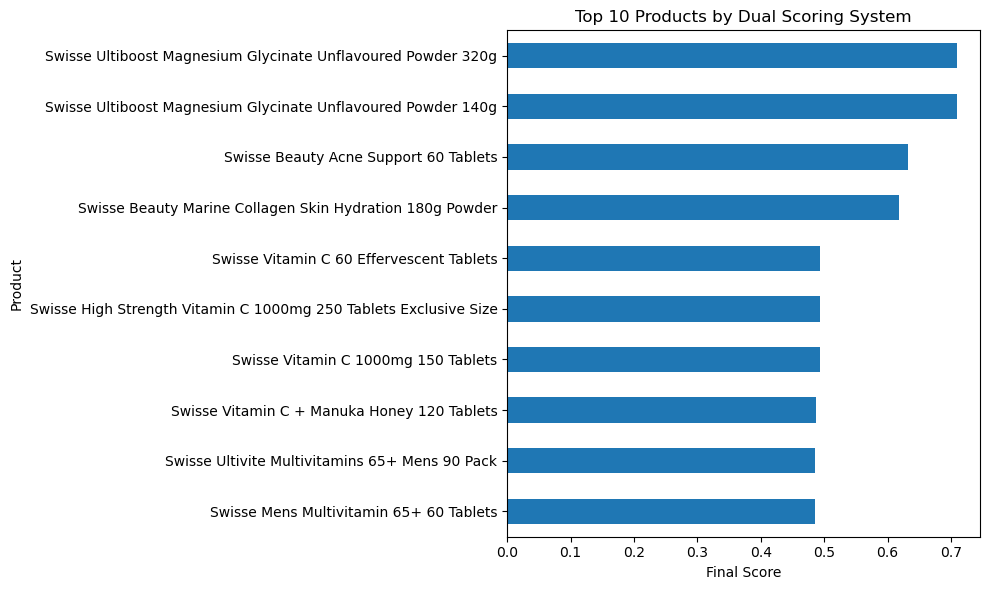

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
top10_products["Final_score"].sort_values().plot(kind="barh")
plt.title("Top 10 Products by Dual Scoring System")
plt.xlabel("Final Score")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [89]:
top10_products[["RDI_mean", "Market_mean", "Coverage", "RDI_norm", "Market_norm", "Coverage_norm", "Final_score"]]

,RDI_mean,Market_mean,Coverage,RDI_norm,Market_norm,Coverage_norm,Final_score
Product,,,,,,,
Swisse Ultiboost Magnesium Glycinate Unflavoured Powder 140g,1.000000,2.708050,1.0,1.000000,0.589600,0.166667,0.710213
Swisse Ultiboost Magnesium Glycinate Unflavoured Powder 320g,1.000000,2.708050,1.0,1.000000,0.589600,0.166667,0.710213
Swisse Beauty Acne Support 60 Tablets,0.866667,1.508638,3.0,0.866667,0.328462,0.500000,0.631872
Swisse Beauty Marine Collagen Skin Hydration 180g Powder,1.000000,1.303515,1.0,1.000000,0.283803,0.166667,0.618474
Swisse Vitamin C 1000mg 150 Tablets,0.500000,3.226665,1.0,0.500000,0.702514,0.166667,0.494087
Swisse High Strength Vitamin C 1000mg 250 Tablets Exclusive Size,0.500000,3.226665,1.0,0.500000,0.702514,0.166667,0.494087
Swisse Vitamin C 60 Effervescent Tablets,0.500000,3.226665,1.0,0.500000,0.702514,0.166667,0.494087
Swisse Vitamin C + Manuka Honey 120 Tablets,0.700000,1.585404,1.0,0.700000,0.345176,0.166667,0.486886
Swisse Mens Multivitamin 65+ 60 Tablets,0.577576,0.452971,5.0,0.577576,0.098621,0.833333,0.485041


你可以怎么理解这个系统

这个系统不是在说：

剂量最大 = 最好

而是在说：

对 Vitamin / Mineral：
看是不是接近人体需要
不是越高越好
对 Structural / Herbal / Fatty Acid：
看它在同类产品里是不是“有料”
对产品整体：
看它是否同时满足
科学合理性
市场竞争力
营养覆盖度